/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.73      0.79      0.76     65070
           2       0.70      0.46      0.55     61671
           3       0.39      0.37      0.38     23801
           4       0.12      0.59      0.19      4110

    accuracy                           0.59    154652
   macro avg       0.48      0.55      0.47    154652
weighted avg       0.65      0.59      0.60    154652



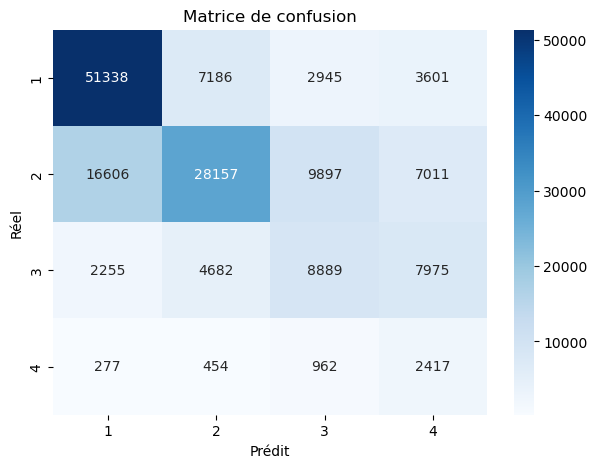

In [1]:
##############
# Logistic Regression with under-sampling sur la v2 après feature engineering
##############
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "accidents_preprocessed_v2.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)



# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['dep'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['dep'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()